# OhioT1DM – Exploratory Data Analysis
**Purpose:** Understand the dataset structure, glucose dynamics, missing data patterns,
physiological feature distributions, stationarity, and feature-target correlations
before any modelling is performed.

> This notebook is **EDA only**. All modelling lives in `main.py` and `src/models/`.

In [1]:
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "configs" / "config.yaml").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root containing configs/config.yaml and src/")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.utils.config_loader import load_config
from src.utils.seed import set_global_seed

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

cfg = load_config(PROJECT_ROOT / "configs" / "config.yaml")
set_global_seed(cfg["seed"])

PROCESSED_DIR = PROJECT_ROOT / "output" / "processed"
PLOTS_DIR = PROJECT_ROOT / cfg["paths"]["plots_dir"]
RESULTS_DIR = PROJECT_ROOT / cfg["paths"]["results_dir"]
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Config loaded. Processed data dir:", PROCESSED_DIR)


Config loaded. Processed data dir: C:\Users\Admin\Desktop\blood-glucose-prediction\output\processed


## 1. Load Processed DataFrames


In [2]:
def load_processed_split(split: str, processed_dir: Path) -> dict[str, pd.DataFrame]:
    split_dir = processed_dir / split
    files = sorted(split_dir.glob(f"*_{split}_master.csv"))
    if not files:
        raise FileNotFoundError(
            f"No processed {split} master CSVs found in {split_dir}. "
            "Run: python scripts/export_master_dataframes.py"
        )

    masters = {}
    suffix = f"_{split}_master.csv"
    for file in files:
        patient_key = file.name.removesuffix(suffix)
        df = pd.read_csv(file, parse_dates=["ts"]).set_index("ts").sort_index()
        df["patient"] = patient_key
        df["split"] = split
        masters[patient_key] = df
    return masters


train_masters = load_processed_split("train", PROCESSED_DIR)
test_masters = load_processed_split("test", PROCESSED_DIR)

patient_keys = sorted(set(train_masters) | set(test_masters))
combined_masters = {}
for key in patient_keys:
    parts = [df for df in [train_masters.get(key), test_masters.get(key)] if df is not None]
    combined_masters[key] = pd.concat(parts).sort_index()

all_data = pd.concat(combined_masters.values()).sort_index()

print(f"Train master DataFrames: {len(train_masters)}")
print(f"Test master DataFrames:  {len(test_masters)}")
print(f"Merged patients:          {len(combined_masters)}")
print(f"Rows after train+test merge: {len(all_data):,}")
display(all_data.head())


Train master DataFrames: 12
Test master DataFrames:  12
Merged patients:          12
Rows after train+test merge: 188,948


,raw_glucose_level,glucose_level,bolus,meal,basal,temp_basal,exercise,basis_gsr,finger_stick,basis_skin_temperature,basis_sleep,total_insulin,insulin_count,insulin_3h_std,daily_exercise,patient,split
ts,,,,,,,,,,,,,,,,,
2021-08-30 11:53:00,116.0,116.0,3.0,0.0,1.143333,0.0,0.0,0.000065,160.0,88.356364,0.0,3.095278,1.0,0.000000,1,588_2018,train
2021-08-30 11:58:00,117.0,117.0,0.0,37.0,1.143333,0.0,0.0,0.000066,114.0,91.400000,0.0,0.095278,0.0,2.121320,1,588_2018,train
2021-08-30 12:03:00,119.0,119.0,5.1,0.0,1.143333,0.0,0.0,0.000066,114.0,91.400000,0.0,5.195278,1.0,2.563201,1,588_2018,train
2021-08-30 12:08:00,116.0,116.0,0.0,0.0,1.143333,0.0,0.0,0.000066,114.0,91.940000,0.0,0.095278,0.0,2.490482,1,588_2018,train
2021-08-30 12:13:00,111.0,111.0,0.0,0.0,1.143333,0.0,0.0,0.000067,114.0,93.200000,0.0,0.095278,0.0,2.339231,1,588_2018,train


## 2. Remaining Missing Data After Imputation


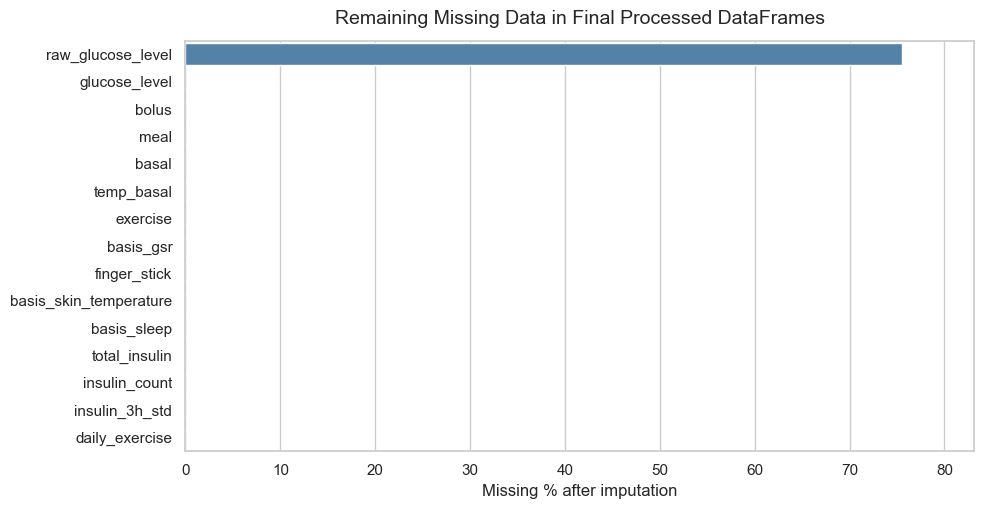

,missing_pct_after_imputation
raw_glucose_level,75.557296
glucose_level,0.000000
bolus,0.000000
meal,0.000000
basal,0.000000
temp_basal,0.000000
exercise,0.000000
basis_gsr,0.000000
finger_stick,0.000000
basis_skin_temperature,0.000000


In [3]:
missing_pct = (
    all_data
    .drop(columns=["patient", "split"], errors="ignore")
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(missing_pct))))
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="steelblue")
ax.set_title("Remaining Missing Data in Final Processed DataFrames", fontsize=14, pad=12)
ax.set_xlabel("Missing % after imputation")
ax.set_ylabel("")
ax.set_xlim(0, max(1, missing_pct.max() * 1.1))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_processed_missingness.png"), bbox_inches="tight")
plt.show()

display(missing_pct.rename("missing_pct_after_imputation").to_frame())


## 3. Glucose Visualisation


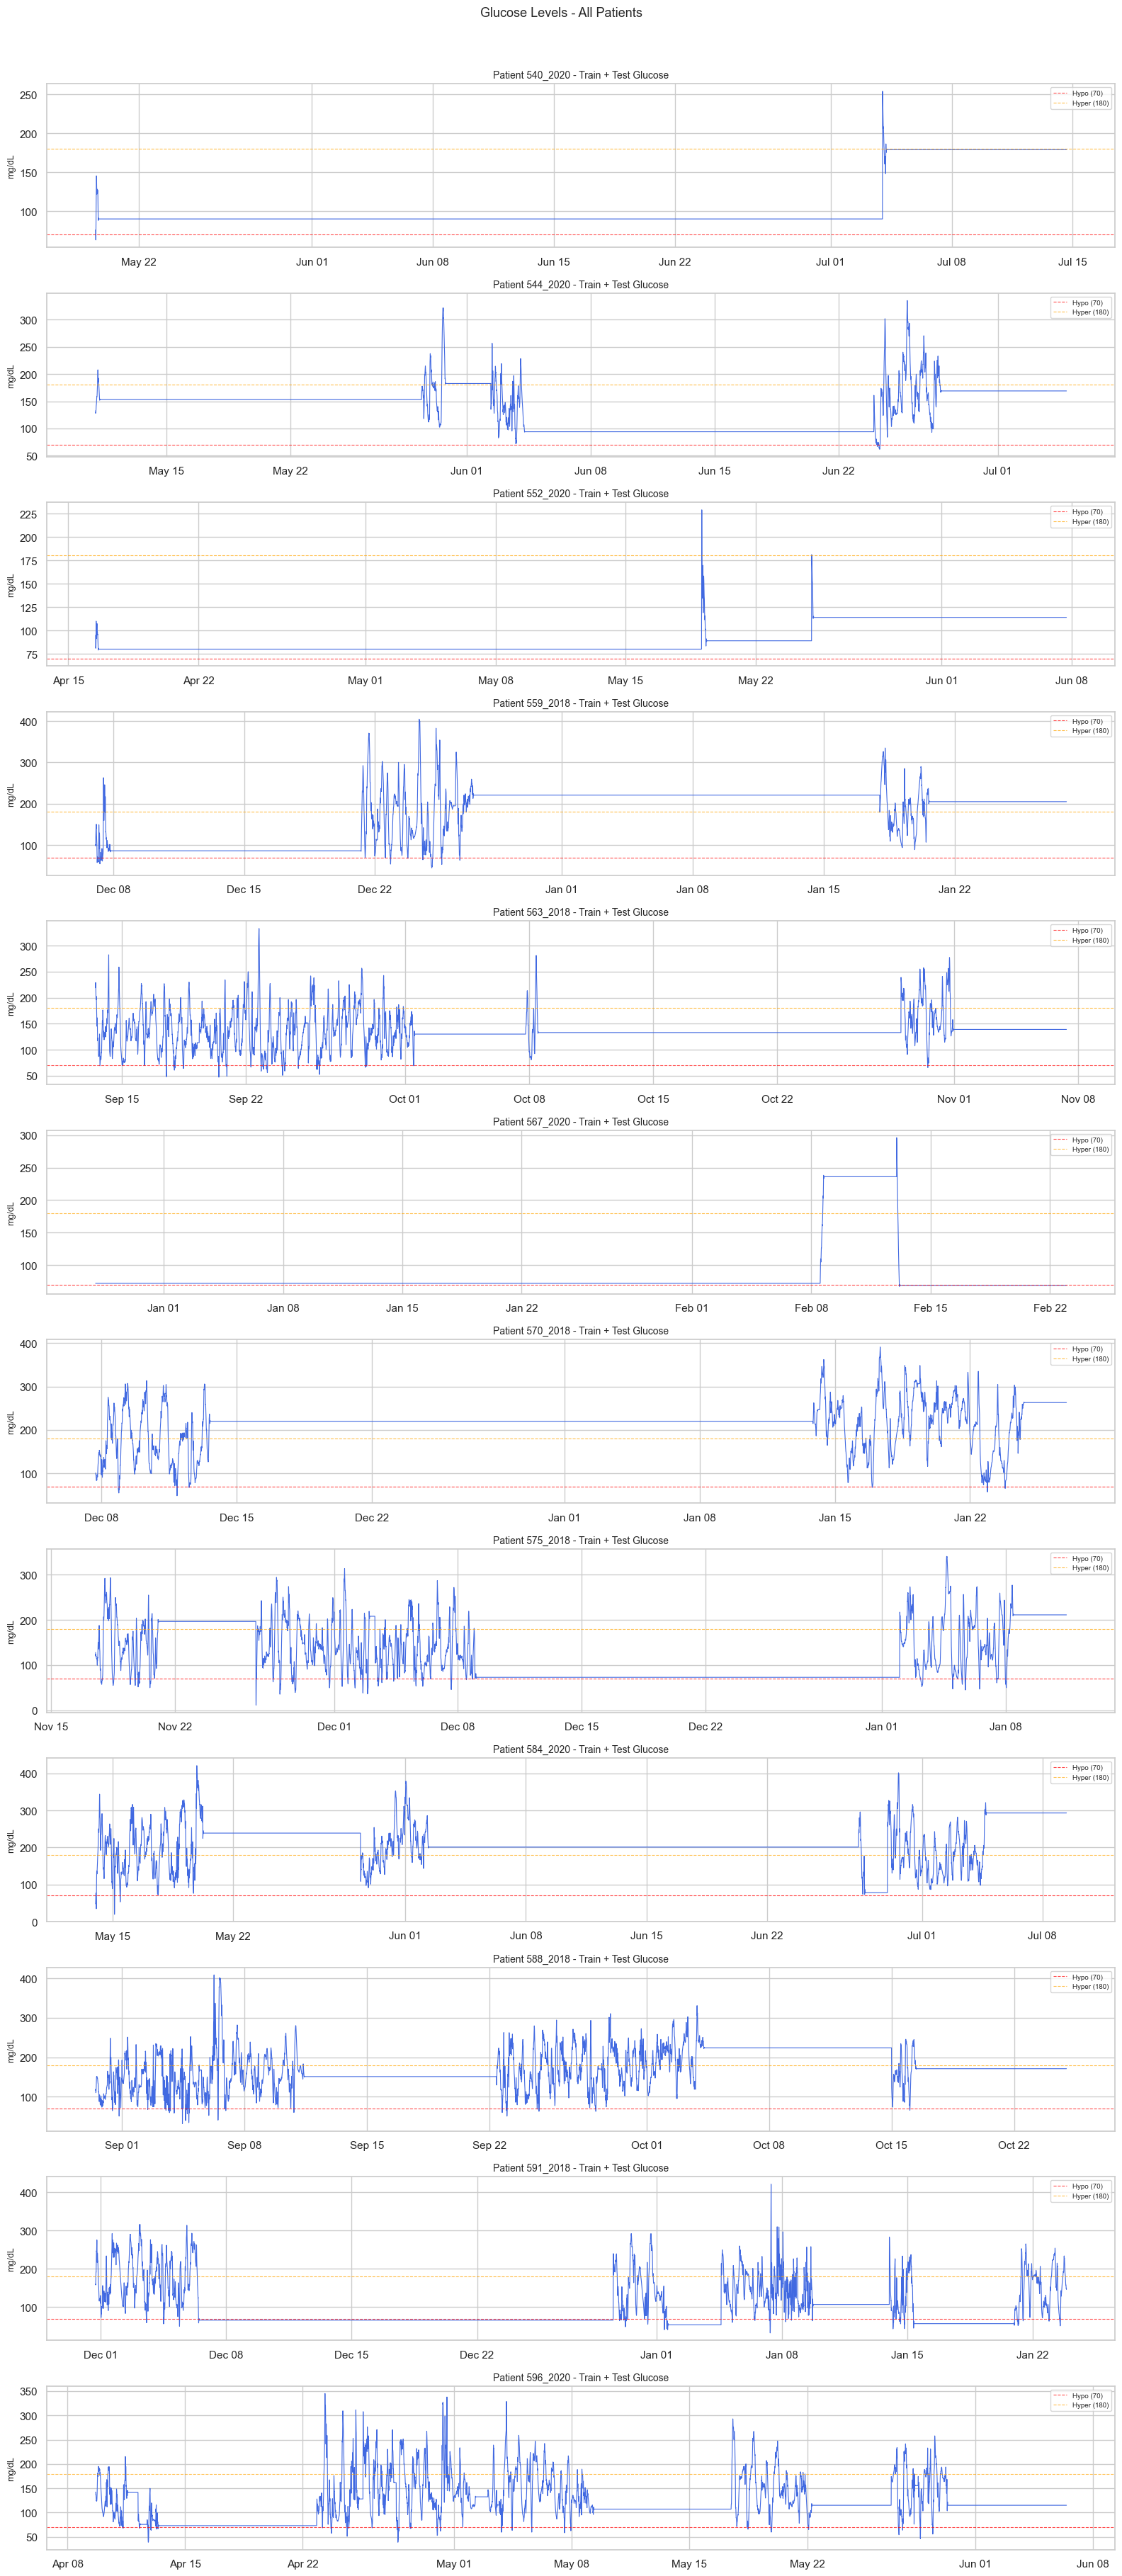

In [4]:
n = len(combined_masters)
fig, axes = plt.subplots(n, 1, figsize=(16, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, (key, df) in zip(axes, sorted(combined_masters.items())):
    ax.plot(df.index, df["glucose_level"], lw=0.8, color="royalblue")
    ax.axhline(70, ls="--", color="red", lw=0.8, alpha=0.7, label="Hypo (70)")
    ax.axhline(180, ls="--", color="orange", lw=0.8, alpha=0.7, label="Hyper (180)")
    ax.set_ylabel("mg/dL", fontsize=9)
    ax.set_title(f"Patient {key} - Train + Test Glucose", fontsize=10)
    ax.legend(fontsize=7, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.suptitle("Glucose Levels - All Patients", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_glucose.png"), bbox_inches="tight")
plt.show()


## 4. Glucose Distribution per Patient


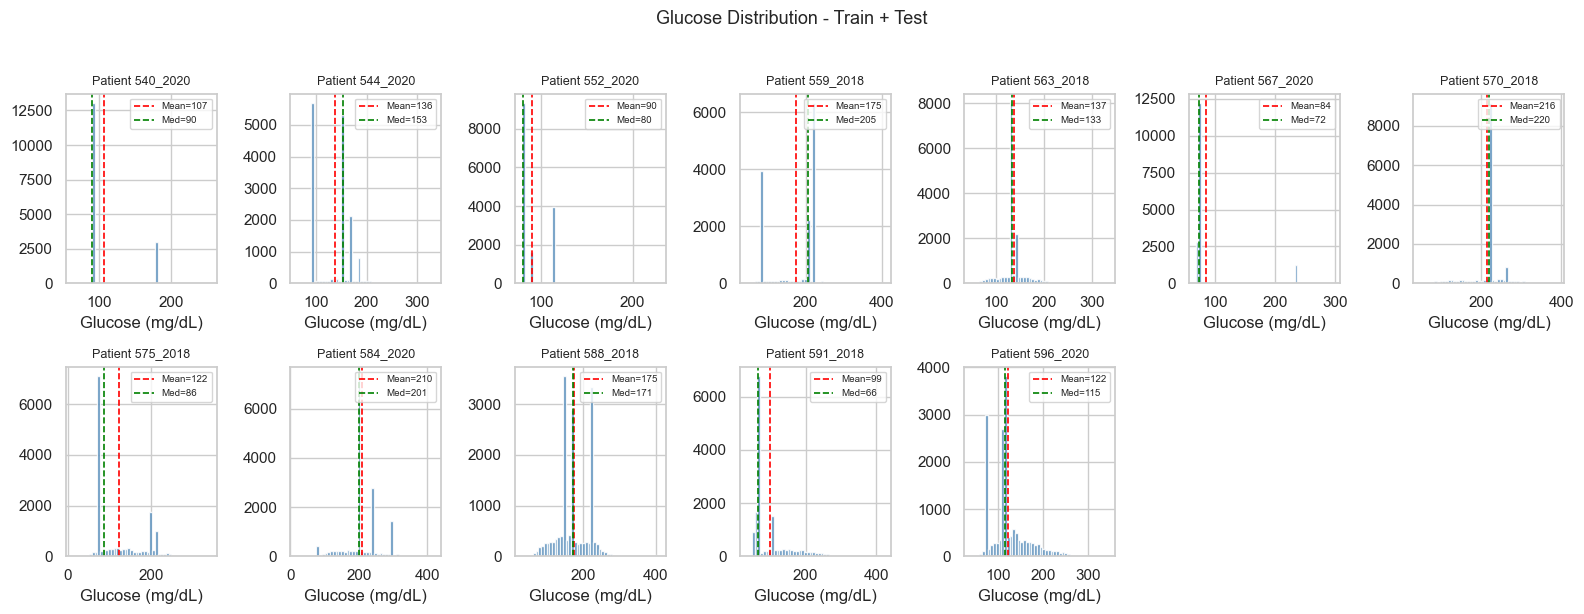

In [5]:
fig, axes = plt.subplots(2, n // 2 + 1, figsize=(16, 6))
axes = axes.flatten()

for i, (key, df) in enumerate(sorted(combined_masters.items())):
    gl = df["glucose_level"].dropna()
    axes[i].hist(gl, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(gl.mean(), color="red", ls="--", lw=1.2, label=f"Mean={gl.mean():.0f}")
    axes[i].axvline(gl.median(), color="green", ls="--", lw=1.2, label=f"Med={gl.median():.0f}")
    axes[i].set_title(f"Patient {key}", fontsize=9)
    axes[i].set_xlabel("Glucose (mg/dL)")
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Glucose Distribution - Train + Test", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_glucose_distributions.png"), bbox_inches="tight")
plt.show()


## 5. Time-in-Range (TIR) Analysis

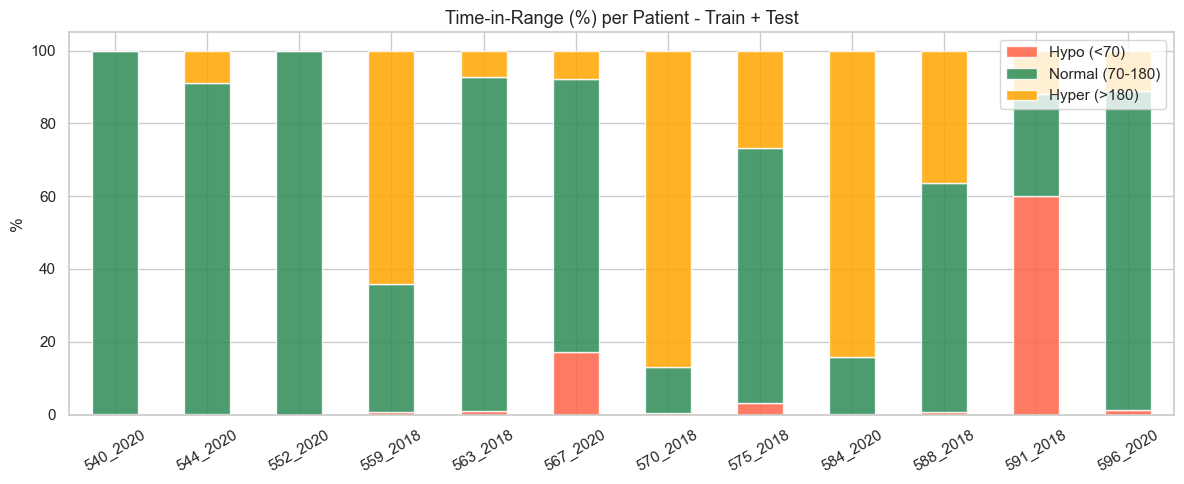

 patient  hypo_pct  normal_pct  hyper_pct
540_2020  0.024731   99.777421   0.197848
544_2020  0.158158   90.966028   8.875815
552_2020  0.000000   99.953479   0.046521
559_2018  0.762236   34.995988  64.241776
563_2018  0.956423   91.651888   7.391690
567_2020 17.208168   75.062481   7.729351
570_2018  0.317460   12.650104  87.032436
575_2018  3.071867   70.267366  26.660767
584_2020  0.160079   15.681566  84.158355
588_2018  0.706913   62.921489  36.371598
591_2018 59.941033   28.175875  11.883092
596_2020  1.226625   87.553364  11.220011


In [6]:
tir_records = []
for key, df in sorted(combined_masters.items()):
    gl = df["glucose_level"].dropna()
    total = len(gl)
    if total == 0:
        continue
    tir_records.append(dict(
        patient=key,
        hypo_pct=(gl < 70).sum() / total * 100,
        normal_pct=((gl >= 70) & (gl <= 180)).sum() / total * 100,
        hyper_pct=(gl > 180).sum() / total * 100,
    ))

tir_df = pd.DataFrame(tir_records)
ax = tir_df.set_index("patient").plot(
    kind="bar", stacked=True, figsize=(12, 5),
    color=["tomato", "seagreen", "orange"], alpha=0.85,
)
ax.set_title("Time-in-Range (%) per Patient - Train + Test", fontsize=13)
ax.set_ylabel("%")
ax.set_xlabel("")
ax.legend(["Hypo (<70)", "Normal (70-180)", "Hyper (>180)"], loc="upper right")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_time_in_range.png"), bbox_inches="tight")
plt.show()
print(tir_df.to_string(index=False))


## 6. Stationarity Check (ADF Test)

In [7]:
adf_records = []
for key, df in sorted(combined_masters.items()):
    series = df["glucose_level"].resample("5min").mean().interpolate().dropna()
    if len(series) < 20 or series.nunique() <= 1:
        continue
    result = adfuller(series, autolag="AIC")
    adf_records.append(dict(
        patient=key,
        adf_stat=round(result[0], 4),
        p_value=round(result[1], 4),
        stationary="Yes" if result[1] < 0.05 else "No",
    ))

adf_df = pd.DataFrame(adf_records)
print("Augmented Dickey-Fuller Stationarity Test - Processed Glucose Level")
display(adf_df)


Augmented Dickey-Fuller Stationarity Test - Processed Glucose Level


,patient,adf_stat,p_value,stationary
0,540_2020,-0.5119,0.8897,No
1,544_2020,-4.6136,0.0001,Yes
2,552_2020,-3.1262,0.0247,Yes
3,559_2018,-5.3523,0.0000,Yes
4,563_2018,-14.8089,0.0000,Yes
5,567_2020,-2.5468,0.1045,No
6,570_2018,-8.7690,0.0000,Yes
7,575_2018,-6.8916,0.0000,Yes
8,584_2020,-8.8625,0.0000,Yes
9,588_2018,-11.1659,0.0000,Yes


## 7. ACF & PACF for a Representative Patient

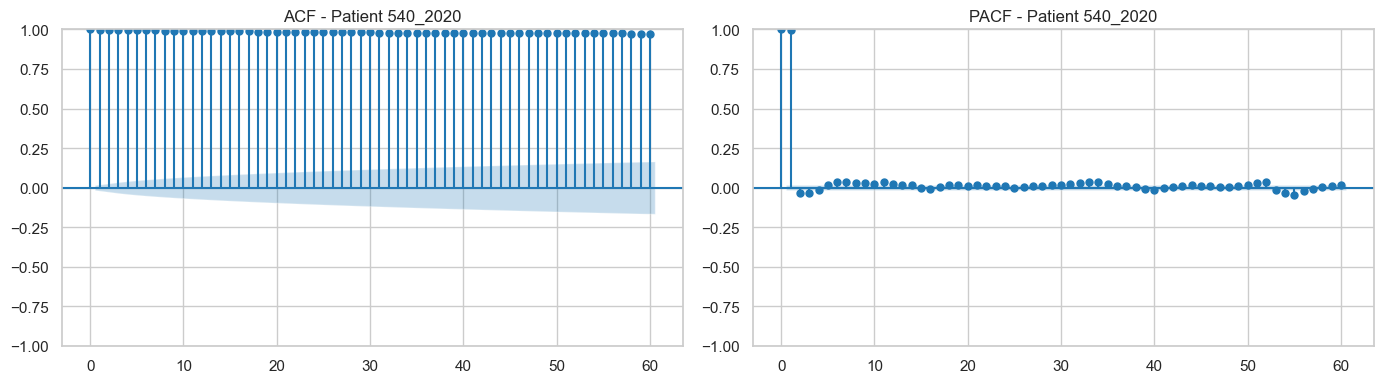

In [8]:
sample_key = sorted(combined_masters.keys())[0]
gl_series = (
    combined_masters[sample_key]["glucose_level"]
    .resample("5min")
    .mean()
    .interpolate()
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(gl_series, lags=60, ax=axes[0], title=f"ACF - Patient {sample_key}")
plot_pacf(gl_series, lags=60, ax=axes[1], title=f"PACF - Patient {sample_key}")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_acf_pacf.png"), bbox_inches="tight")
plt.show()


## 8. Processed Feature Correlation Analysis


In [9]:
feature_cols = [
    col for col in ["total_insulin", "insulin_count", "insulin_3h_std", "daily_exercise"]
    if col in all_data.columns
]

print("Feature columns:", feature_cols)


Feature columns: ['total_insulin', 'insulin_count', 'insulin_3h_std', 'daily_exercise']


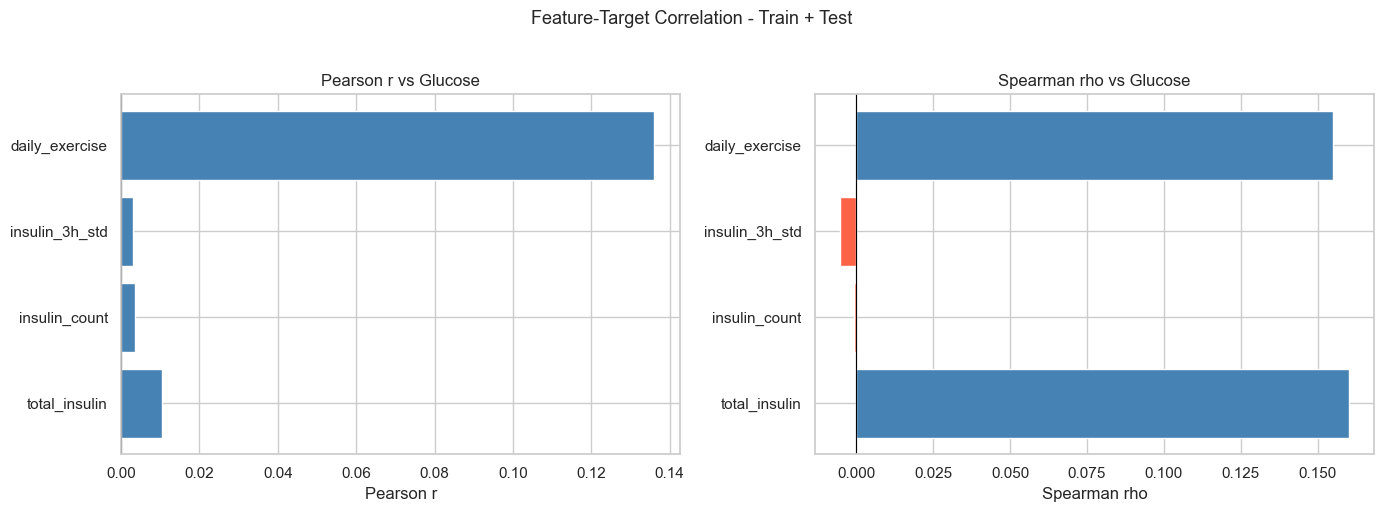


Pearson:


,r,p-value
total_insulin,0.0104,0.0000
insulin_count,0.0035,0.1265
insulin_3h_std,0.0031,0.1745
daily_exercise,0.1359,0.0000



Spearman:


,r,p-value
total_insulin,0.1600,0.0000
insulin_count,-0.0008,0.7275
insulin_3h_std,-0.0052,0.0242
daily_exercise,0.1549,0.0000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pearson_r, spearman_r = {}, {}

corr_data = all_data.dropna(subset=["glucose_level"])
for col in feature_cols:
    valid = corr_data[[col, "glucose_level"]].dropna()
    if len(valid) < 3 or valid[col].nunique() <= 1:
        continue
    r, p = stats.pearsonr(valid[col], valid["glucose_level"])
    pearson_r[col] = (round(r, 4), round(p, 4))
    r2, p2 = stats.spearmanr(valid[col], valid["glucose_level"])
    spearman_r[col] = (round(r2, 4), round(p2, 4))

pearson_df = pd.DataFrame(pearson_r, index=["r", "p-value"]).T
spearman_df = pd.DataFrame(spearman_r, index=["r", "p-value"]).T

for ax, corr_df, title, xlabel in [
    (axes[0], pearson_df, "Pearson r vs Glucose", "Pearson r"),
    (axes[1], spearman_df, "Spearman rho vs Glucose", "Spearman rho"),
]:
    colors = ["steelblue" if v >= 0 else "tomato" for v in corr_df["r"]]
    ax.barh(corr_df.index, corr_df["r"], color=colors)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)

plt.suptitle("Feature-Target Correlation - Train + Test", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_correlation.png"), bbox_inches="tight")
plt.show()

print("\nPearson:"); display(pearson_df)
print("\nSpearman:"); display(spearman_df)


## 9. Engineered Feature Distributions


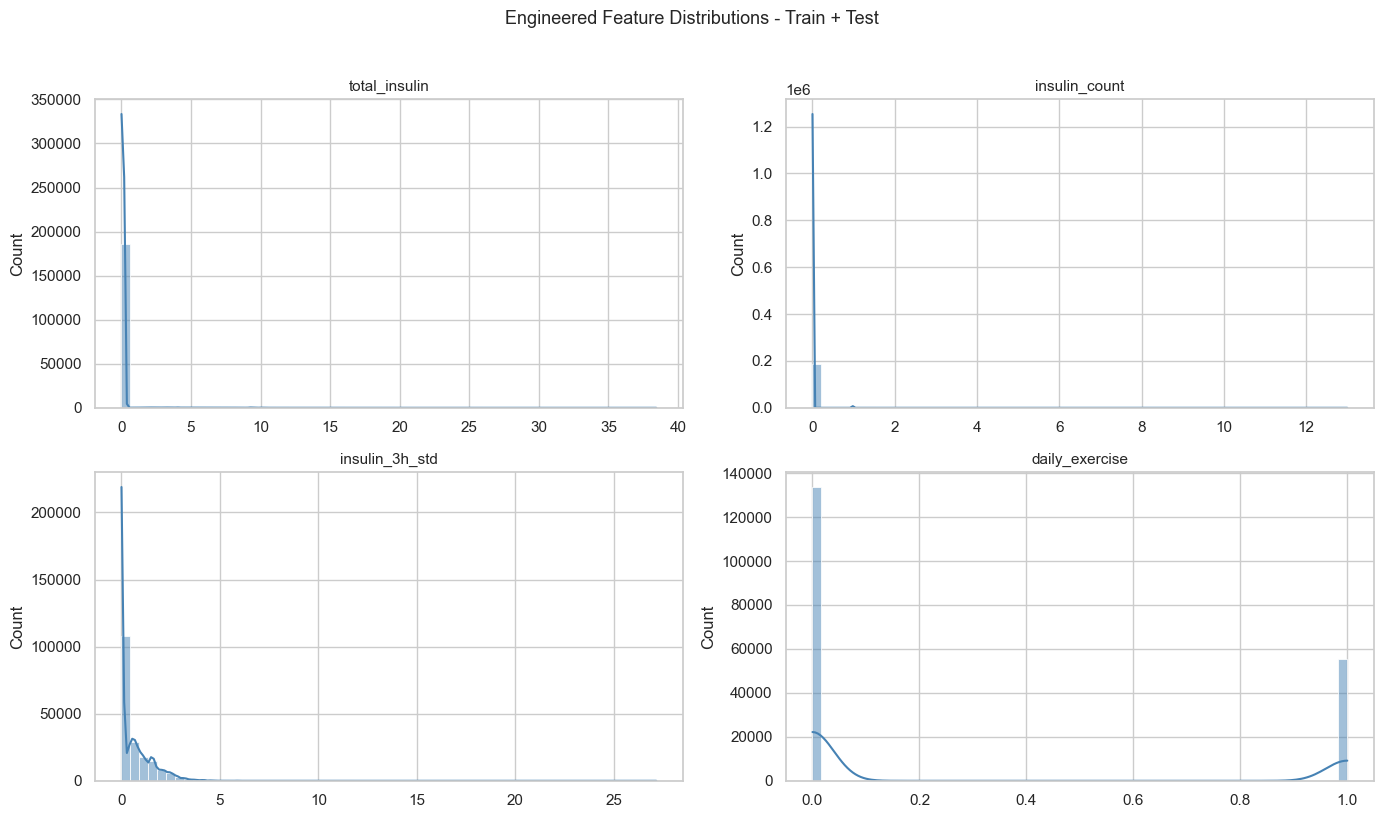

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    data = all_data[col].dropna()
    sns.histplot(data, bins=60, ax=ax, color="steelblue", kde=True)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")

for ax in axes.flatten()[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle("Engineered Feature Distributions - Train + Test", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_feature_distributions.png"), bbox_inches="tight")
plt.show()


## 10. Insulin vs Glucose Relationship


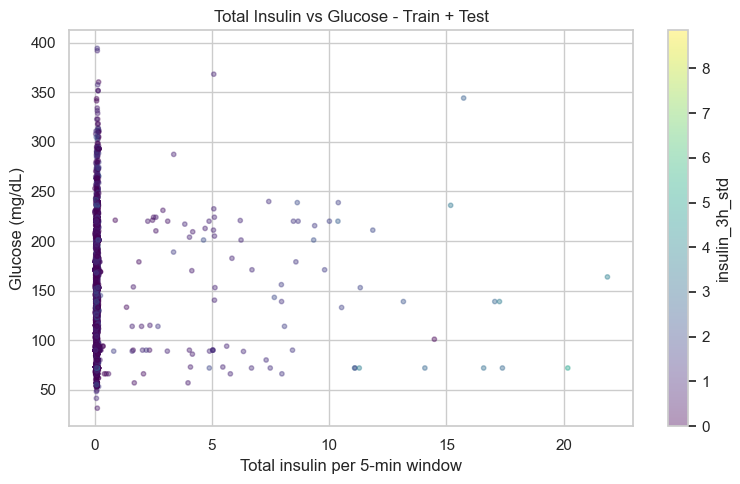

In [12]:
sample = all_data.sample(min(5000, len(all_data)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    sample["total_insulin"],
    sample["glucose_level"],
    c=sample["insulin_3h_std"],
    cmap="viridis",
    alpha=0.4,
    s=10,
)
plt.colorbar(sc, ax=ax, label="insulin_3h_std")
ax.set_xlabel("Total insulin per 5-min window")
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title("Total Insulin vs Glucose - Train + Test")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_insulin_glucose_scatter.png"), bbox_inches="tight")
plt.show()


## 11. Summary Statistics for Final DataFrames


In [13]:
summary = all_data.drop(columns=["patient", "split"], errors="ignore").describe().T
display(summary)
summary.to_csv(RESULTS_DIR / "eda_summary_stats.csv")
print("EDA complete. Plots saved to:", PLOTS_DIR)


,count,mean,std,min,25%,50%,75%,max
raw_glucose_level,46184.0,162.440975,60.019455,40.000000,117.000000,154.000000,202.000000,400.000000
glucose_level,188948.0,138.912685,61.930440,11.811364,84.122378,129.214785,196.966783,420.832168
bolus,188948.0,0.117568,1.044147,0.000000,0.000000,0.000000,0.000000,38.400000
meal,188948.0,0.520852,6.105201,0.000000,0.000000,0.000000,0.000000,450.000000
basal,188948.0,1.007881,0.397821,0.000000,0.730000,0.980000,1.250000,2.000000
temp_basal,188948.0,0.010831,0.122742,0.000000,0.000000,0.000000,0.000000,2.340000
exercise,188948.0,0.105690,0.752679,0.000000,0.000000,0.000000,0.000000,10.000000
basis_gsr,188948.0,0.811664,3.515698,0.000000,0.000056,0.000156,0.096307,75.074353
finger_stick,188948.0,163.067609,74.854782,0.000000,113.000000,155.000000,208.000000,586.000000
basis_skin_temperature,188948.0,67.290189,36.927088,0.000000,79.520000,86.236000,88.880000,110.660000


EDA complete. Plots saved to: C:\Users\Admin\Desktop\blood-glucose-prediction\output\plots
